<a href="https://colab.research.google.com/github/YuSeokGeun/Data-Analysis-with-Open-Source/blob/main/%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C%EB%AC%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

문 1-2

In [ ]:
import requests
import json

vrty_codes = {
    '01': '봄',
    '02': '여름(고랭지)',
    '03': '가을',
    '06': '월동'
}

all_data = []

for year in range(2015, 2025):
    for code, name in vrty_codes.items():

        url = (
            "https://apis.data.go.kr/B552845/perDay/price"
            "?serviceKey=aGmQheGTwMiEGAA%2B3jddp9U5OAzI0fXwUHgjtE%2FkHCMvjniXE1NCpUElJu3UcZTRvmSzIZeBLpnT641OSpuZSA%3D%3D"
            "&returnType=JSON"
            "&pageNo=1"
            "&numOfRows=200"
            f"&cond[exmn_ymd::GTE]={year}0101"
            f"&cond[exmn_ymd::LTE]={year}1231"
            "&cond[se_cd::EQ]=02"
            "&cond[ctgry_cd::EQ]=200"
            "&cond[item_cd::EQ]=211"
            "&cond[grd_cd::EQ]=04"
            "&cond[sgg_cd::EQ]=1101"
            "&cond[mrkt_cd::EQ]=0110211"
            f"&cond[vrty_cd::EQ]={code}"
        )

        response = requests.get(url)
        data = response.json()['response']['body']['items']['item']

        for item in data:
            all_data.append(item)

        print(f"{year}년 / {name}({code}) / 총 {len(data)}건")

with open('가락시장_배추가격_2015_2024.json', mode='w', encoding='utf-8') as f:
    json.dump(all_data, f, indent=4, ensure_ascii=False)

print('전체 데이터 수:', len(all_data))


2015년 / 봄(01) / 총 66건
2015년 / 여름(고랭지)(02) / 총 64건
2015년 / 가을(03) / 총 45건
2015년 / 월동(06) / 총 97건
2016년 / 봄(01) / 총 70건
2016년 / 여름(고랭지)(02) / 총 72건
2016년 / 가을(03) / 총 48건
2016년 / 월동(06) / 총 87건
2017년 / 봄(01) / 총 67건
2017년 / 여름(고랭지)(02) / 총 57건
2017년 / 가을(03) / 총 48건
2017년 / 월동(06) / 총 86건
2018년 / 봄(01) / 총 48건
2018년 / 여름(고랭지)(02) / 총 74건
2018년 / 가을(03) / 총 48건
2018년 / 월동(06) / 총 94건
2019년 / 봄(01) / 총 43건
2019년 / 여름(고랭지)(02) / 총 65건
2019년 / 가을(03) / 총 53건
2019년 / 월동(06) / 총 97건
2020년 / 봄(01) / 총 51건
2020년 / 여름(고랭지)(02) / 총 66건
2020년 / 가을(03) / 총 64건
2020년 / 월동(06) / 총 101건
2021년 / 봄(01) / 총 46건
2021년 / 여름(고랭지)(02) / 총 74건
2021년 / 가을(03) / 총 31건
2021년 / 월동(06) / 총 105건
2022년 / 봄(01) / 총 39건
2022년 / 여름(고랭지)(02) / 총 86건
2022년 / 가을(03) / 총 40건
2022년 / 월동(06) / 총 91건
2023년 / 봄(01) / 총 48건
2023년 / 여름(고랭지)(02) / 총 69건
2023년 / 가을(03) / 총 35건
2023년 / 월동(06) / 총 105건
2024년 / 봄(01) / 총 53건
2024년 / 여름(고랭지)(02) / 총 74건
2024년 / 가을(03) / 총 35건
2024년 / 월동(06) / 총 102건
전체 데이터 수: 2644


문 2-1

In [140]:
import json
import pandas as pd

with open('가락시장_배추가격_2015_2024.json', mode = 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print('### shape ###')
print(df.shape)
print('\n')

print('### describe ###')
print(df.describe())
print('\n')

print('### info ###')
df.info()
print('\n')

print('### head ###')
df.head(10)

### shape ###
(2644, 20)


### describe ###
       ctgry_cd ctgry_nm exmn_dd_cnvs_prc exmn_dd_prc  exmn_ymd grd_cd grd_nm  \
count      2644     2644             2644        2644      2644   2644   2644   
unique        1        1              189         189      2458      1      1   
top         200      채소류            10000       10000  20241217     04     상품   
freq       2644     2644              218         218         2   2644   2644   

       item_cd item_nm  mrkt_cd mrkt_nm          orgnl_reg_dt se_cd se_nm  \
count     2644    2644     2644    2644                  2644  2644  2644   
unique       1       1        1       1                  2458     1     1   
top        211      배추  0110211    가락도매  2024-12-27T13:41:43Z    02   중도매   
freq      2644    2644     2644    2644                     2  2644  2644   

       sgg_cd sgg_nm         unit unit_sz vrty_cd vrty_nm  
count    2644   2644         2644    2644    2644    2644  
unique      1      1            1       1   

,ctgry_cd,ctgry_nm,exmn_dd_cnvs_prc,exmn_dd_prc,exmn_ymd,grd_cd,grd_nm,item_cd,item_nm,mrkt_cd,mrkt_nm,orgnl_reg_dt,se_cd,se_nm,sgg_cd,sgg_nm,unit,unit_sz,vrty_cd,vrty_nm
0,200,채소류,9000,9000,20150512,04,상품,211,배추,0110211,가락도매,2015-05-12T13:53:35Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
1,200,채소류,8000,8000,20150513,04,상품,211,배추,0110211,가락도매,2015-05-13T13:47:27Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
2,200,채소류,8000,8000,20150514,04,상품,211,배추,0110211,가락도매,2015-05-18T14:51:22Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
3,200,채소류,8000,8000,20150515,04,상품,211,배추,0110211,가락도매,2015-05-18T14:57:50Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
4,200,채소류,10000,10000,20150518,04,상품,211,배추,0110211,가락도매,2015-05-21T11:25:53Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
5,200,채소류,11000,11000,20150519,04,상품,211,배추,0110211,가락도매,2015-05-21T11:28:26Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
6,200,채소류,11000,11000,20150520,04,상품,211,배추,0110211,가락도매,2015-05-21T11:30:54Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
7,200,채소류,11000,11000,20150521,04,상품,211,배추,0110211,가락도매,2015-05-21T14:00:54Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
8,200,채소류,10000,10000,20150522,04,상품,211,배추,0110211,가락도매,2015-05-22T14:05:30Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄
9,200,채소류,10000,10000,20150526,04,상품,211,배추,0110211,가락도매,2015-05-26T14:02:18Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄


문 2-2

In [ ]:
import json
import pandas as pd

with open('가락시장_배추가격_2015_2024.json', mode = 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['year'] = df['exmn_ymd'].astype(str).str[:4]
df['season'] = df['exmn_ymd'].astype(str).str[4:6].astype(int).apply(get_season)

print(df[['exmn_ymd', 'year', 'season']].head(100))

    exmn_ymd  year season
0   20150512  2015      봄
1   20150513  2015      봄
2   20150514  2015      봄
3   20150515  2015      봄
4   20150518  2015      봄
..       ...   ...    ...
95  20150918  2015     가을
96  20150921  2015     가을
97  20150922  2015     가을
98  20150923  2015     가을
99  20150924  2015     가을

[100 rows x 3 columns]


문 3-1

In [ ]:
!apt-get -qq install fonts-nanum

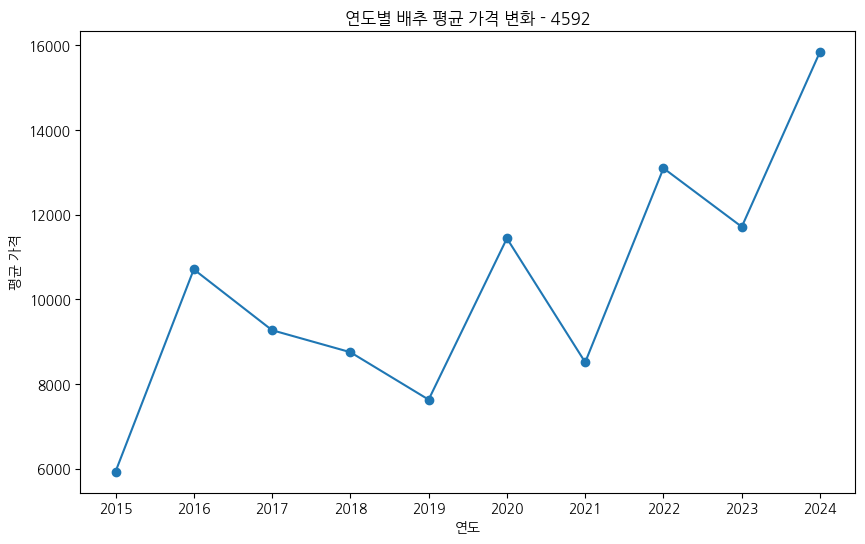

In [ ]:
import matplotlib.pyplot as plt

df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

year_price_mean = df.groupby('year')['exmn_dd_prc'].mean()
# print(year_price_mean)

plt.figure(figsize=(10, 6))
plt.plot(year_price_mean.index, year_price_mean.values, marker='o')

plt.title('연도별 배추 평균 가격 변화 - 4592')
plt.xlabel('연도')
plt.ylabel('평균 가격')

plt.xticks(year_price_mean.index)
plt.show()

문 3-2

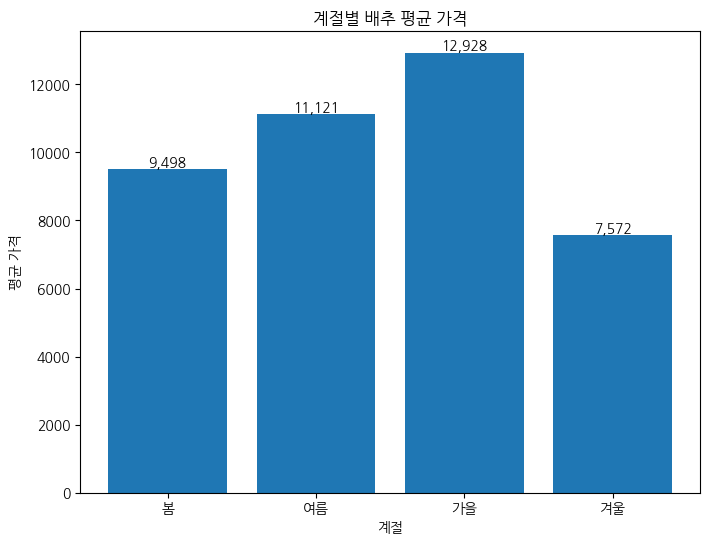

In [ ]:
season_name = ['봄', '여름', '가을', '겨울']
season_price_mean = df.groupby('season')['exmn_dd_prc'].mean().reindex(season_name)
# print(season_price_mean)

plt.figure(figsize = (8, 6))

bars = plt.bar(season_price_mean.index, season_price_mean.values)

plt.title('계절별 배추 평균 가격')
plt.xlabel('계절')
plt.ylabel('평균 가격')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()